In [ ]:
!pip install pyquaternion
!pip install nuscenes-devkit efficientnet_pytorch==0.7.0

In [ ]:
import torch
import numpy as np
from glob import glob

np.set_printoptions(precision=3)
%matplotlib inline

In [ ]:
# download code
!wget https://raw.githubusercontent.com/yandexdataschool/sdc_course/refs/heads/spring2025_camera_only/seminar04-camera-only/src/__init__.py
!wget https://raw.githubusercontent.com/yandexdataschool/sdc_course/refs/heads/spring2025_camera_only/seminar04-camera-only/src/data.py
!wget https://raw.githubusercontent.com/yandexdataschool/sdc_course/refs/heads/spring2025_camera_only/seminar04-camera-only/src/explore.py
!wget https://raw.githubusercontent.com/yandexdataschool/sdc_course/refs/heads/spring2025_camera_only/seminar04-camera-only/src/models.py
!wget https://raw.githubusercontent.com/yandexdataschool/sdc_course/refs/heads/spring2025_camera_only/seminar04-camera-only/src/tools.py
!wget https://raw.githubusercontent.com/yandexdataschool/sdc_course/refs/heads/spring2025_camera_only/seminar04-camera-only/src/train.py

In [ ]:
!mkdir -p /data/sets/nuscenes  # Make the directory to store the nuScenes dataset in.

!wget https://www.nuscenes.org/data/v1.0-mini.tgz  # Download the nuScenes mini split.

!tar -xf v1.0-mini.tgz -C /data/sets/nuscenes  # Uncompress the nuScenes mini split.

In [ ]:
# source download

import requests
from urllib.parse import urlencode
import os


# based on https://ru.stackoverflow.com/a/1088518
def download_from_yadisk(short_url: str, filename: str, target_dir: str):
    base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'

    final_url = base_url + urlencode(dict(public_key=short_url))
    response = requests.get(final_url)
    download_url = response.json()['href']

    download_response = requests.get(download_url)
    target_file = os.path.join(target_dir, filename)
    with open(target_file, 'wb') as f:
        f.write(download_response.content)

In [ ]:
# for task 1
download_from_yadisk("https://disk.yandex.ru/d/l0_zM_F39leAPQ", 
                               "depth_data.zip",
                               target_dir='.')
!unzip depth_data.zip

Camera plane -> 3D

Pinhole camera model

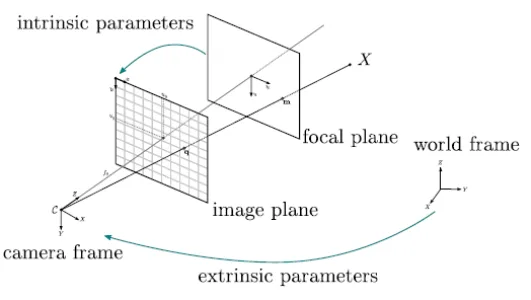

У камеры есть внешние параметры (экстринсики) - это матрица трансформации камеры относительно какого-то выбранного центра координат (обычно центр машины или робота). Состоит из матрицы поворота и трансформаций. Пример:

```
extrins = np.array([[ 0.01013525, -0.9998445 ,  0.01443031, -0.02844296],
                    [ 0.00327788, -0.01439775, -0.999891  ,  0.40777844],
                    [ 0.99994326,  0.01018144,  0.00313145, -0.3445946 ],
                    [ 0.        ,  0.        ,  0.        ,  1.        ]])
```

Также есть интринсики - матрица преобразования 3d координат объектов в координатах камеры на плоскость камеры. Пример:

```
intrins = np.array([[466.788,   0.   , 511.5],
                    [  0.   , 466.788, 269.5],
                    [  0.   ,   0.   ,   1.]])
```

Они состоят из f-чисел (фокусного расстояния) и координат принципиальной точки (cx, cy). Можно данную матрицу представить так

```
intrins = np.array([[fx,   0., cx],
                    [0.,   fy, cy],
                    [0.,   0.,  1.]])
```

ЗАДАНИЕ 1. Реализовать самостоятельно функцию 2d depth -> 3d point cloud. Как тест решения - функцию обратного преобразования (3d -> 2d). 



На вход: карта глубины (1, h, w), интринсики (3, 3)
На выход: массив (N, 3), где в последней мерности координаты x, y, z



Для упрощения задачи будем считать, что экстринсики в нашем случае - единичная матрица



БОНУС: сделать визуализацию и того и другого

In [ ]:
# ячейка для задания 1
depth1 = np.load("depth_data/depth1.npy")
depth2 = np.load("depth_data/depth2.npy")
depth3 = np.load("depth_data/depth3.npy")

intrinsics = [366.778564453125, 0.0, 318.3612365722656, 0.0, 0.0, 366.778564453125, 176.17840576171875, 0.0, 0.0, 0.0, 1.0, 0.0]

TLDR: Что такое Lift-Splat-Shot модель?

Это одна из базовых camera-only моделей, может быть включена в большую perception модель (например, BEV-Fusion), может быть использована самостоятельно.

Состоит из трёх этапов:

1. Lift (Подъём): На этом этапе изображения, полученные с камер, проецируются в трёхмерное пространство. Это делается с использованием информации о интринсиках камеры и глубине (или псевдоглубине), чтобы определить, где каждый пиксель изображения находится в трёхмерном пространстве.

2. Splat ("Разбрызгивание"): После проекции данных в 3D-пространство, они  распределяются по трёхмерной сетке (Frutsum). Это позволяет создать плотное представление сцены, где каждый элемент сетки содержит информацию о своём окружении.

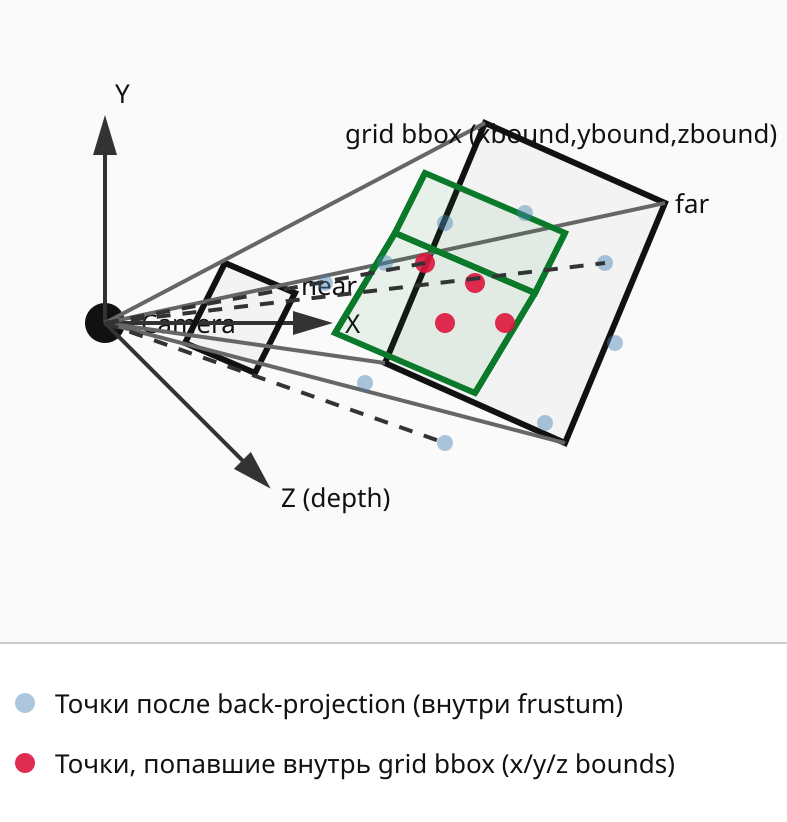

3. Shoot: На последнем этапе модель использует полученное трёхмерное представление для выполнения различных задач, таких как обнаружение объектов, оценка расстояний или прогнозирование движения. Это позволяет системе принимать решения на основе более полной информации о сцене.

Параметры модели LSS

In [ ]:
# размер изображения

H=900
W=1600

# размеры на вход и на выход
resize_lim=(0.193, 0.225)
final_dim=(128, 352)
bot_pct_lim=(0.0, 0.22)
rot_lim=(-5.4, 5.4)
rand_flip=True

# параметры грида

xbound=[-50.0, 50.0, 0.5]
ybound=[-50.0, 50.0, 0.5]
zbound=[-10.0, 10.0, 20.0]
dbound=[4.0, 45.0, 1.0]

In [ ]:
grid_conf = {
        'xbound': xbound,
        'ybound': ybound,
        'zbound': zbound,
        'dbound': dbound,
    }
    
    
data_aug_conf = {
                    'resize_lim': resize_lim,
                    'final_dim': final_dim,
                    'rot_lim': rot_lim,
                    'H': H, 'W': W,
                    'rand_flip': rand_flip,
                    'bot_pct_lim': bot_pct_lim,
                    'cams': ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
                             'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'],
                    'Ncams': 5,
                }

In [ ]:
# download pretrained model
download_from_yadisk("https://disk.yandex.ru/d/m5xDFY8JnWsUhg", 
                               "model_pretrained.pt",
                               target_dir='.')

In [ ]:
from data import compile_data
from tools import (ego_to_cam, get_only_in_img_mask, denormalize_img,
                    SimpleLoss, get_val_info, add_ego, gen_dx_bx,
                    get_nusc_maps, plot_nusc_map, visualize_binmgs)
from models import compile_model

In [ ]:
# тест данных Nuscense
trainloader, valloader = compile_data("mini", "/data/sets/nuscenes", data_aug_conf=data_aug_conf,
                                          grid_conf=grid_conf, bsz=4, nworkers=1,
                                          parser_name='segmentationdata')


In [ ]:
device = torch.device(f'cuda:0')

model = compile_model(grid_conf, data_aug_conf, outC=1)
model.load_state_dict(torch.load('model_pretrained.pt'))
model.to(device)

loss_fn = SimpleLoss(1.0).cuda(0)

model.eval()

In [ ]:
# запуск одной итерации LSS на val

with torch.no_grad():
    for batch in valloader:
        allimgs, rots, trans, intrins, post_rots, post_trans, binimgs = batch
        preds = model(allimgs.to(device), rots.to(device),
                          trans.to(device), intrins.to(device), post_rots.to(device),
                          post_trans.to(device))
        binimgs = binimgs.to(device)
        break

In [ ]:
scene_num = 3

In [ ]:
bin_im = (binimgs[scene_num][0].detach().cpu().numpy()).astype(np.uint8) * 250
preds_im = (preds[scene_num][0].detach().cpu().numpy()).astype(np.uint8) * 250

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
img = plt.imshow(bin_im)
plt.show()

In [ ]:
img = plt.imshow(preds_im)
plt.show()

ЗАДАНИЕ 2: Посчитать метрики, заявленные в paper на данных Nuscense (функция eval_model_iou из explore). 

In [ ]:
# ячейка для задания 2

ЗАДАНИЕ 3: сделать визуализацию проекции BEV-сегментации на изображение

In [ ]:
# ячейка для задания 3